# SVM Sosmed(TF-IDF + LinearSVC) dengan Train/Test Split, 5-Fold CV, Pipeline, dan Artefak Lengkap

In [655]:
import os, json, joblib, random, warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from datetime import datetime

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

RANDOM_STATE = 42
DATA_PATH = "/content/drive/MyDrive/TRAINING SKRIPSI/Dataset Sosmed Final.xlsx" # UPDATE THIS PATH to your file in Google Drive
TEXT_COLUMN = "text"
LABEL_COLUMN = "sentiment"

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

BASE_OUTPUT_DIR = os.path.join("outputs","svm",RUN_ID)
ROS_OUTPUT_DIR = os.path.join(BASE_OUTPUT_DIR, "with_ros")
NO_ROS_OUTPUT_DIR = os.path.join(BASE_OUTPUT_DIR, "without_ros")

os.makedirs(ROS_OUTPUT_DIR, exist_ok=True)
os.makedirs(NO_ROS_OUTPUT_DIR, exist_ok=True)

print("BASE_OUTPUT_DIR:", BASE_OUTPUT_DIR)
print("ROS_OUTPUT_DIR:", ROS_OUTPUT_DIR)
print("NO_ROS_OUTPUT_DIR:", NO_ROS_OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE_OUTPUT_DIR: outputs/svm/20260723_153549
ROS_OUTPUT_DIR: outputs/svm/20260723_153549/with_ros
NO_ROS_OUTPUT_DIR: outputs/svm/20260723_153549/without_ros


In [656]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

set_seed(RANDOM_STATE)


In [657]:
df = pd.read_excel(DATA_PATH)
df = df[[TEXT_COLUMN, LABEL_COLUMN]].dropna()

print(df.shape)
df.head()


(3585, 2)


,text,sentiment
0,kpu - komisi pemilihan umum indonesia gila baj...,negative
1,mahfud md klaim tak ada data penting yang boco...,negative
2,"bjorka diduga kuat orang asli indonesia, forum...",neutral
3,"tegaskan tak ada data negara bocor, mahfud md:...",negative
4,"terbaru, bjorka bocorkan data menko polhukam m...",negative


In [658]:
label_names = sorted(df[LABEL_COLUMN].astype(str).unique().tolist())
print(label_names)


['negative', 'neutral', 'positive']


In [659]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df[LABEL_COLUMN],
    random_state=RANDOM_STATE
)

print("Train:", train_df.shape)
print("Test :", test_df.shape)


Train: (2868, 2)
Test : (717, 2)


In [660]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=RANDOM_STATE)
X_train_oversampled, y_train_oversampled = ros.fit_resample(train_df[TEXT_COLUMN].values.reshape(-1, 1), train_df[LABEL_COLUMN])

# Convert back to DataFrame for consistency if needed, or extract directly
# For this pipeline, we will pass X_train_oversampled directly to fit after reshaping if necessary.

train_df_oversampled = pd.DataFrame({TEXT_COLUMN: X_train_oversampled.flatten(), LABEL_COLUMN: y_train_oversampled})

print("Original Train shape:", train_df.shape)
print("Oversampled Train shape:", train_df_oversampled.shape)
print("\nOriginal Train label distribution:")
print(train_df[LABEL_COLUMN].value_counts())
print("\nOversampled Train label distribution:")
print(train_df_oversampled[LABEL_COLUMN].value_counts())

# To use the oversampled data, you would replace `train_df` with `train_df_oversampled` in the subsequent training steps.

Original Train shape: (2868, 2)
Oversampled Train shape: (4386, 2)

Original Train label distribution:
sentiment
negative    1462
neutral      796
positive     610
Name: count, dtype: int64

Oversampled Train label distribution:
sentiment
negative    1462
positive    1462
neutral     1462
Name: count, dtype: int64


In [661]:
train_df[LABEL_COLUMN].value_counts().sort_index().to_csv(
    os.path.join(ROS_OUTPUT_DIR,"train_label_distribution.csv")
)

test_df[LABEL_COLUMN].value_counts().sort_index().to_csv(
    os.path.join(ROS_OUTPUT_DIR,"test_label_distribution.csv")
)

In [662]:
SVM_CONFIG = {
    "model": "LinearSVC",
    "vectorizer": "TFIDF",
    "max_features": 20000,
    "ngram_range": (1, 2),
    "min_df": 3,
    "max_df": 0.80,
    "sublinear_tf": True,
    "C": 1,
    "class_weight": "balanced",
    "n_splits": 10,
    "random_state": RANDOM_STATE,
}

def build_svm_pipeline(config):
    return Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    max_features=config["max_features"],
                    ngram_range=config["ngram_range"],
                    min_df=config["min_df"],
                    max_df=config["max_df"],
                    sublinear_tf=config["sublinear_tf"]
                )
            ),
            (
                "svm",
                LinearSVC(
                    C=config["C"],
                    class_weight=config["class_weight"],
                    random_state=config["random_state"],
                )
            )
        ]
    )

In [663]:
def save_confusion_matrix(y_true,y_pred,save_path,title):
    cm = confusion_matrix(y_true,y_pred)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_names,
        yticklabels=label_names
    )

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.tight_layout()
    plt.savefig(save_path,dpi=300,bbox_inches="tight")
    plt.show()


In [664]:
from imblearn.over_sampling import RandomOverSampler

cv_df = train_df.reset_index(drop=True) # Use original train_df for splitting into folds

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

fold_rows = []

for fold,(tr_idx,val_idx) in enumerate(
    skf.split(cv_df[TEXT_COLUMN],cv_df[LABEL_COLUMN]),start=1
):

    fold_train = cv_df.iloc[tr_idx]
    fold_val = cv_df.iloc[val_idx]

    # Apply RandomOverSampler ONLY to the training part of the current fold
    ros_fold = RandomOverSampler(random_state=RANDOM_STATE)
    X_fold_train_resampled, y_fold_train_resampled = ros_fold.fit_resample(
        fold_train[TEXT_COLUMN].values.reshape(-1, 1),
        fold_train[LABEL_COLUMN]
    )

    model = build_svm_pipeline(SVM_CONFIG)

    model.fit(
        X_fold_train_resampled.flatten(), # Pass the flattened 1D array to TfidfVectorizer
        y_fold_train_resampled
    )

    preds = model.predict(
        fold_val[TEXT_COLUMN]
    )

    acc = accuracy_score(fold_val[LABEL_COLUMN],preds)
    mf1 = f1_score(fold_val[LABEL_COLUMN],preds,average="macro")
    mpre = precision_score(fold_val[LABEL_COLUMN],preds,average="macro",zero_division=0)
    mrec = recall_score(fold_val[LABEL_COLUMN],preds,average="macro",zero_division=0)

    fold_rows.append({
        "Fold":fold,
        "Accuracy":acc,
        "Macro_F1":mf1,
        "Macro_Precision":mpre,
        "Macro_Recall":mrec
    })

    report = classification_report(
        fold_val[LABEL_COLUMN],
        preds,
        output_dict=True,
        zero_division=0
    )

    pd.DataFrame(report).transpose().to_csv(
        os.path.join(
            ROS_OUTPUT_DIR,
            f"fold_{fold}_classification_report.csv"
        )
    )

fold_df = pd.DataFrame(fold_rows)

mean_row = pd.DataFrame([
    {
        "Fold":"Mean",
        "Accuracy":fold_df["Accuracy"].mean(),
        "Macro_F1":fold_df["Macro_F1"].mean(),
        "Macro_Precision":fold_df["Macro_Precision"].mean(),
        "Macro_Recall":fold_df["Macro_Recall"].mean()
    }
])

cv_folds = pd.concat([fold_df,mean_row],ignore_index=True)

cv_folds.to_csv(
    os.path.join(ROS_OUTPUT_DIR,"cv_folds.csv"),
    index=False
)

summary_df = pd.DataFrame([
    {
        "Model":"SVM",
        "Mean_Accuracy":fold_df["Accuracy"].mean(),
        "Mean_Macro_F1":fold_df["Macro_F1"].mean(),
        "Mean_Macro_Precision":fold_df["Macro_Precision"].mean(),
        "Mean_Macro_Recall":fold_df["Macro_Recall"].mean(),
        "Std_Accuracy":fold_df["Accuracy"].std(),
        "Std_Macro_F1":fold_df["Macro_F1"].std()
    }
])

summary_df.to_csv(
    os.path.join(ROS_OUTPUT_DIR,"cv_summary.csv"),
    index=False
)

display(cv_folds)
display(summary_df)

,Fold,Accuracy,Macro_F1,Macro_Precision,Macro_Recall
0,1,0.780488,0.769759,0.767064,0.778399
1,2,0.768293,0.762588,0.755056,0.772050
2,3,0.752613,0.745555,0.746684,0.745812
3,4,0.753927,0.741886,0.736204,0.749301
4,5,0.759162,0.748804,0.748122,0.750180
5,Mean,0.762897,0.753718,0.750626,0.759148


,Model,Mean_Accuracy,Mean_Macro_F1,Mean_Macro_Precision,Mean_Macro_Recall,Std_Accuracy,Std_Macro_F1
0,SVM,0.762897,0.753718,0.750626,0.759148,0.011605,0.011903


In [665]:
final_model_ros = build_svm_pipeline(SVM_CONFIG)

final_model_ros.fit(
    train_df_oversampled[TEXT_COLUMN],
    train_df_oversampled[LABEL_COLUMN]
)

joblib.dump(
    final_model_ros,
    os.path.join(ROS_OUTPUT_DIR,"svm_model_ros.joblib")
)

['outputs/svm/20260723_153549/with_ros/svm_model_ros.joblib']

In [666]:
test_preds_ros = final_model_ros.predict(
    test_df[TEXT_COLUMN]
)

test_acc_ros = accuracy_score(test_df[LABEL_COLUMN],test_preds_ros)
test_f1_ros = f1_score(test_df[LABEL_COLUMN],test_preds_ros,average="macro")
test_prec_ros = precision_score(test_df[LABEL_COLUMN],test_preds_ros,average="macro",zero_division=0)
test_rec_ros = recall_score(test_df[LABEL_COLUMN],test_preds_ros,average="macro",zero_division=0)

final_metrics_ros = pd.DataFrame([
    {
        "Accuracy":test_acc_ros,
        "Macro_F1":test_f1_ros,
        "Macro_Precision":test_prec_ros,
        "Macro_Recall":test_rec_ros
    }
])

final_metrics_ros.to_csv(
    os.path.join(ROS_OUTPUT_DIR,"final_test_metrics_ros.csv"),
    index=False
)

display(final_metrics_ros)

,Accuracy,Macro_F1,Macro_Precision,Macro_Recall
0,0.772664,0.768304,0.762419,0.777065


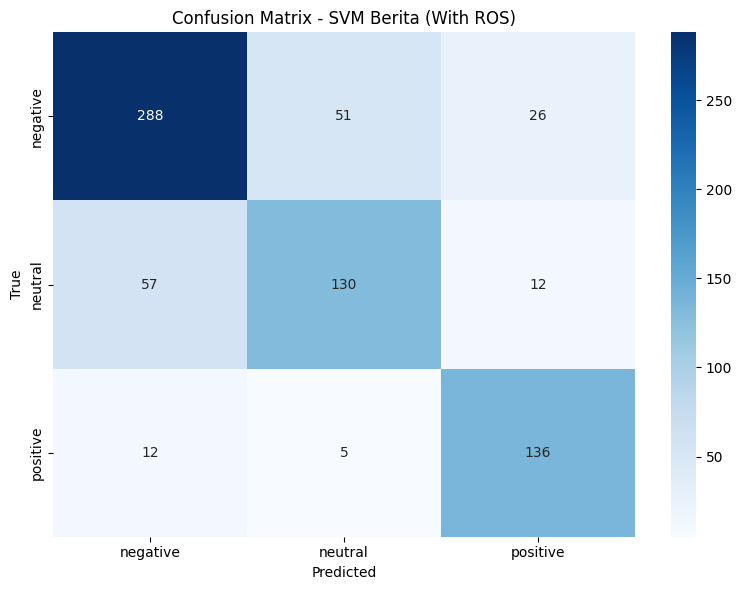

In [667]:
report_ros = classification_report(
    test_df[LABEL_COLUMN],
    test_preds_ros,
    output_dict=True,
    zero_division=0
)

pd.DataFrame(report_ros).transpose().to_csv(
    os.path.join(ROS_OUTPUT_DIR,"classification_report_test_ros.csv")
)

save_confusion_matrix(
    test_df[LABEL_COLUMN],
    test_preds_ros,
    os.path.join(ROS_OUTPUT_DIR,"confusion_matrix_test_ros.png"),
    "Confusion Matrix - SVM Berita (With ROS)"
)

## Tanpa Random OverSampler (NO ROS)

In [668]:
print('Distribusi label data pelatihan (tanpa ROS):')
train_df[LABEL_COLUMN].value_counts().sort_index().to_csv(
    os.path.join(NO_ROS_OUTPUT_DIR,"train_label_distribution.csv")
)
display(train_df[LABEL_COLUMN].value_counts().sort_index().to_frame())

Distribusi label data pelatihan (tanpa ROS):


,count
sentiment,
negative,1462
neutral,796
positive,610


### Cross-Validation Tanpa ROS

In [669]:
cv_df_no_ros = train_df.reset_index(drop=True) # Use original train_df for splitting into folds

skf_no_ros = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

fold_rows_no_ros = []

for fold,(tr_idx,val_idx) in enumerate(
    skf_no_ros.split(cv_df_no_ros[TEXT_COLUMN],cv_df_no_ros[LABEL_COLUMN]),start=1
):

    fold_train_no_ros = cv_df_no_ros.iloc[tr_idx]
    fold_val_no_ros = cv_df_no_ros.iloc[val_idx]

    # No RandomOverSampler applied here

    model_no_ros = build_svm_pipeline(SVM_CONFIG)

    model_no_ros.fit(
        fold_train_no_ros[TEXT_COLUMN], # Use original training data for this fold
        fold_train_no_ros[LABEL_COLUMN]
    )

    preds_no_ros = model_no_ros.predict(
        fold_val_no_ros[TEXT_COLUMN]
    )

    acc_no_ros = accuracy_score(fold_val_no_ros[LABEL_COLUMN],preds_no_ros)
    mf1_no_ros = f1_score(fold_val_no_ros[LABEL_COLUMN],preds_no_ros,average="macro")
    mpre_no_ros = precision_score(fold_val_no_ros[LABEL_COLUMN],preds_no_ros,average="macro",zero_division=0)
    mrec_no_ros = recall_score(fold_val_no_ros[LABEL_COLUMN],preds_no_ros,average="macro",zero_division=0)

    fold_rows_no_ros.append({
        "Fold":fold,
        "Accuracy":acc_no_ros,
        "Macro_F1":mf1_no_ros,
        "Macro_Precision":mpre_no_ros,
        "Macro_Recall":mrec_no_ros
    })

    report_no_ros = classification_report(
        fold_val_no_ros[LABEL_COLUMN],
        preds_no_ros,
        output_dict=True,
        zero_division=0
    )

    pd.DataFrame(report_no_ros).transpose().to_csv(
        os.path.join(
            NO_ROS_OUTPUT_DIR,
            f"fold_{fold}_classification_report_no_ros.csv"
        )
    )

fold_df_no_ros = pd.DataFrame(fold_rows_no_ros)

mean_row_no_ros = pd.DataFrame([
    {
        "Fold":"Mean",
        "Accuracy":fold_df_no_ros["Accuracy"].mean(),
        "Macro_F1":fold_df_no_ros["Macro_F1"].mean(),
        "Macro_Precision":fold_df_no_ros["Macro_Precision"].mean(),
        "Macro_Recall":fold_df_no_ros["Macro_Recall"].mean()
    }
])

cv_folds_no_ros = pd.concat([fold_df_no_ros,mean_row_no_ros],ignore_index=True)

cv_folds_no_ros.to_csv(
    os.path.join(NO_ROS_OUTPUT_DIR,"cv_folds_no_ros.csv"),
    index=False
)

summary_df_no_ros = pd.DataFrame([
    {
        "Model":"SVM",
        "Mean_Accuracy":fold_df_no_ros["Accuracy"].mean(),
        "Mean_Macro_F1":fold_df_no_ros["Macro_F1"].mean(),
        "Mean_Macro_Precision":fold_df_no_ros["Macro_Precision"].mean(),
        "Mean_Macro_Recall":fold_df_no_ros["Macro_Recall"].mean(),
        "Std_Accuracy":fold_df_no_ros["Accuracy"].std(),
        "Std_Macro_F1":fold_df_no_ros["Macro_F1"].std()
    }
])

summary_df_no_ros.to_csv(
    os.path.join(NO_ROS_OUTPUT_DIR,"cv_summary_no_ros.csv"),
    index=False
)

print("Hasil Cross-Validation Tanpa ROS:")
display(cv_folds_no_ros)
display(summary_df_no_ros)

Hasil Cross-Validation Tanpa ROS:


,Fold,Accuracy,Macro_F1,Macro_Precision,Macro_Recall
0,1,0.780488,0.770224,0.765171,0.781911
1,2,0.764808,0.760857,0.751001,0.774559
2,3,0.761324,0.755100,0.751712,0.760059
3,4,0.753927,0.744697,0.735487,0.758528
4,5,0.755672,0.751067,0.742813,0.761896
5,Mean,0.763244,0.756389,0.749237,0.767391


,Model,Mean_Accuracy,Mean_Macro_F1,Mean_Macro_Precision,Mean_Macro_Recall,Std_Accuracy,Std_Macro_F1
0,SVM,0.763244,0.756389,0.749237,0.767391,0.010579,0.009722


### Pelatihan Model Akhir Tanpa ROS

In [670]:
final_model_no_ros = build_svm_pipeline(SVM_CONFIG)

final_model_no_ros.fit(
    train_df[TEXT_COLUMN], # Train on original training data
    train_df[LABEL_COLUMN]
)

joblib.dump(
    final_model_no_ros,
    os.path.join(NO_ROS_OUTPUT_DIR,"svm_model_no_ros.joblib")
)
print('Model akhir tanpa ROS berhasil dilatih dan disimpan.')

Model akhir tanpa ROS berhasil dilatih dan disimpan.


### Evaluasi Model Akhir Tanpa ROS pada Data Uji

In [671]:
test_preds_no_ros = final_model_no_ros.predict(
    test_df[TEXT_COLUMN]
)

test_acc_no_ros = accuracy_score(test_df[LABEL_COLUMN],test_preds_no_ros)
test_f1_no_ros = f1_score(test_df[LABEL_COLUMN],test_preds_no_ros,average="macro")
test_prec_no_ros = precision_score(test_df[LABEL_COLUMN],test_preds_no_ros,average="macro",zero_division=0)
test_rec_no_ros = recall_score(test_df[LABEL_COLUMN],test_preds_no_ros,average="macro",zero_division=0)

final_metrics_no_ros = pd.DataFrame([
    {
        "Accuracy":test_acc_no_ros,
        "Macro_F1":test_f1_no_ros,
        "Macro_Precision":test_prec_no_ros,
        "Macro_Recall":test_rec_no_ros
    }
])

final_metrics_no_ros.to_csv(
    os.path.join(NO_ROS_OUTPUT_DIR,"final_test_metrics_no_ros.csv"),
    index=False
)

print("Metrik Evaluasi Model Akhir Tanpa ROS:")
display(final_metrics_no_ros)

Metrik Evaluasi Model Akhir Tanpa ROS:


,Accuracy,Macro_F1,Macro_Precision,Macro_Recall
0,0.764296,0.759761,0.751783,0.771082


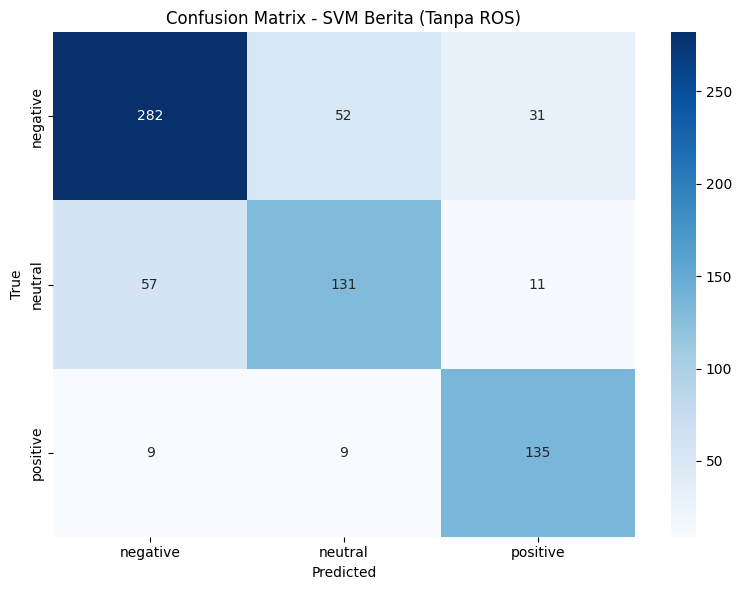

Laporan klasifikasi dan confusion matrix model tanpa ROS berhasil disimpan dan ditampilkan.


In [672]:
report_no_ros = classification_report(
    test_df[LABEL_COLUMN],
    test_preds_no_ros,
    output_dict=True,
    zero_division=0
)

pd.DataFrame(report_no_ros).transpose().to_csv(
    os.path.join(NO_ROS_OUTPUT_DIR,"classification_report_test_no_ros.csv")
)

save_confusion_matrix(
    test_df[LABEL_COLUMN],
    test_preds_no_ros,
    os.path.join(NO_ROS_OUTPUT_DIR,"confusion_matrix_test_no_ros.png"),
    "Confusion Matrix - SVM Berita (Tanpa ROS)"
)
print("Laporan klasifikasi dan confusion matrix model tanpa ROS berhasil disimpan dan ditampilkan.")

## Perbandingan Hasil: Dengan ROS vs Tanpa ROS

## Analisis Dataset Berita Daring

### Konfigurasi dan Direktori Output untuk Dataset Berita Daring

Silakan perbarui `DATA_PATH_NEWS` dengan lokasi file dataset berita daring Anda di Google Drive.

In [673]:
DATA_PATH_NEWS = "/content/drive/MyDrive/TRAINING SKRIPSI/1. Dataset Berita Daring.xlsx" # UPDATE THIS PATH to your news dataset file in Google Drive

RUN_ID_NEWS = datetime.now().strftime("%Y%m%d_%H%M%S")

BASE_OUTPUT_DIR_NEWS = os.path.join("outputs","svm_news",RUN_ID_NEWS)
ROS_OUTPUT_DIR_NEWS = os.path.join(BASE_OUTPUT_DIR_NEWS, "with_ros")
NO_ROS_OUTPUT_DIR_NEWS = os.path.join(BASE_OUTPUT_DIR_NEWS, "without_ros")

os.makedirs(ROS_OUTPUT_DIR_NEWS, exist_ok=True)
os.makedirs(NO_ROS_OUTPUT_DIR_NEWS, exist_ok=True)

print("BASE_OUTPUT_DIR_NEWS:", BASE_OUTPUT_DIR_NEWS)
print("ROS_OUTPUT_DIR_NEWS:", ROS_OUTPUT_DIR_NEWS)
print("NO_ROS_OUTPUT_DIR_NEWS:", NO_ROS_OUTPUT_DIR_NEWS)

BASE_OUTPUT_DIR_NEWS: outputs/svm_news/20260723_153556
ROS_OUTPUT_DIR_NEWS: outputs/svm_news/20260723_153556/with_ros
NO_ROS_OUTPUT_DIR_NEWS: outputs/svm_news/20260723_153556/without_ros


### Pemuatan dan Pembersihan Data Berita Daring

In [674]:
df_news = pd.read_excel(DATA_PATH_NEWS)
df_news = df_news[[TEXT_COLUMN, LABEL_COLUMN]].dropna()

print("Shape Dataset Berita Daring:", df_news.shape)
display(df_news.head())

Shape Dataset Berita Daring: (1608, 2)


,text,sentiment
0,5 cara menjaga data pribadi tetap aman kasus k...,positive
1,rapat paripurna dpr putuskan perpanjang waktu ...,positive
2,kominfo bahas dim ruu perlindungan data pribad...,positive
3,jika uu perlindungan data pribadi masuk proleg...,positive
4,ruu fintech wajib beritahu nasabah menteri jik...,negative


### Pembagian Data Pelatihan dan Pengujian Berita Daring

In [675]:
label_names_news = sorted(df_news[LABEL_COLUMN].astype(str).unique().tolist())
print("Label Names Berita Daring:", label_names_news)

train_df_news, test_df_news = train_test_split(
    df_news,
    test_size=0.20,
    stratify=df_news[LABEL_COLUMN],
    random_state=RANDOM_STATE
)

print("Train News:", train_df_news.shape)
print("Test News :", test_df_news.shape)

Label Names Berita Daring: ['negative', 'neutral', 'positive']
Train News: (1286, 2)
Test News : (322, 2)


### Penanganan Ketidakseimbangan Kelas dengan Random OverSampler (ROS) pada Dataset Berita Daring

In [676]:
ros_news = RandomOverSampler(random_state=RANDOM_STATE)
X_train_oversampled_news, y_train_oversampled_news = ros_news.fit_resample(train_df_news[TEXT_COLUMN].values.reshape(-1, 1), train_df_news[LABEL_COLUMN])

train_df_oversampled_news = pd.DataFrame({TEXT_COLUMN: X_train_oversampled_news.flatten(), LABEL_COLUMN: y_train_oversampled_news})

print("Original Train News shape:", train_df_news.shape)
print("Oversampled Train News shape:", train_df_oversampled_news.shape)
print("\nOriginal Train News label distribution:")
print(train_df_news[LABEL_COLUMN].value_counts())
print("\nOversampled Train News label distribution:")
print(train_df_oversampled_news[LABEL_COLUMN].value_counts())

Original Train News shape: (1286, 2)
Oversampled Train News shape: (1734, 2)

Original Train News label distribution:
sentiment
neutral     578
negative    498
positive    210
Name: count, dtype: int64

Oversampled Train News label distribution:
sentiment
neutral     578
positive    578
negative    578
Name: count, dtype: int64


In [677]:
train_df_oversampled_news[LABEL_COLUMN].value_counts().sort_index().to_csv(
    os.path.join(ROS_OUTPUT_DIR_NEWS,"train_label_distribution.csv")
)

test_df_news[LABEL_COLUMN].value_counts().sort_index().to_csv(
    os.path.join(ROS_OUTPUT_DIR_NEWS,"test_label_distribution.csv")
)

### Cross-Validation dengan ROS pada Dataset Berita Daring

In [678]:
cv_df_news = train_df_news.reset_index(drop=True)

skf_news = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

fold_rows_news_ros = []

for fold,(tr_idx,val_idx) in enumerate(
    skf_news.split(cv_df_news[TEXT_COLUMN],cv_df_news[LABEL_COLUMN]),start=1
):

    fold_train_news = cv_df_news.iloc[tr_idx]
    fold_val_news = cv_df_news.iloc[val_idx]

    ros_fold_news = RandomOverSampler(random_state=RANDOM_STATE)
    X_fold_train_resampled_news, y_fold_train_resampled_news = ros_fold_news.fit_resample(
        fold_train_news[TEXT_COLUMN].values.reshape(-1, 1),
        fold_train_news[LABEL_COLUMN]
    )

    model_news_ros = build_svm_pipeline(SVM_CONFIG)

    model_news_ros.fit(
        X_fold_train_resampled_news.flatten(),
        y_fold_train_resampled_news
    )

    preds_news_ros = model_news_ros.predict(
        fold_val_news[TEXT_COLUMN]
    )

    acc_news_ros = accuracy_score(fold_val_news[LABEL_COLUMN],preds_news_ros)
    mf1_news_ros = f1_score(fold_val_news[LABEL_COLUMN],preds_news_ros,average="macro")
    mpre_news_ros = precision_score(fold_val_news[LABEL_COLUMN],preds_news_ros,average="macro",zero_division=0)
    mrec_news_ros = recall_score(fold_val_news[LABEL_COLUMN],preds_news_ros,average="macro",zero_division=0)

    fold_rows_news_ros.append({
        "Fold":fold,
        "Accuracy":acc_news_ros,
        "Macro_F1":mf1_news_ros,
        "Macro_Precision":mpre_news_ros,
        "Macro_Recall":mrec_news_ros
    })

    report_news_ros = classification_report(
        fold_val_news[LABEL_COLUMN],
        preds_news_ros,
        output_dict=True,
        zero_division=0
    )

    pd.DataFrame(report_news_ros).transpose().to_csv(
        os.path.join(
            ROS_OUTPUT_DIR_NEWS,
            f"fold_{fold}_classification_report.csv"
        )
    )

fold_df_news_ros = pd.DataFrame(fold_rows_news_ros)

mean_row_news_ros = pd.DataFrame([
    {
        "Fold":"Mean",
        "Accuracy":fold_df_news_ros["Accuracy"].mean(),
        "Macro_F1":fold_df_news_ros["Macro_F1"].mean(),
        "Macro_Precision":fold_df_news_ros["Macro_Precision"].mean(),
        "Macro_Recall":fold_df_news_ros["Macro_Recall"].mean()
    }
])

cv_folds_news_ros = pd.concat([fold_df_news_ros,mean_row_news_ros],ignore_index=True)

cv_folds_news_ros.to_csv(
    os.path.join(ROS_OUTPUT_DIR_NEWS,"cv_folds.csv"),
    index=False
)

summary_df_news_ros = pd.DataFrame([
    {
        "Model":"SVM",
        "Mean_Accuracy":fold_df_news_ros["Accuracy"].mean(),
        "Mean_Macro_F1":fold_df_news_ros["Macro_F1"].mean(),
        "Mean_Macro_Precision":fold_df_news_ros["Macro_Precision"].mean(),
        "Mean_Macro_Recall":fold_df_news_ros["Macro_Recall"].mean(),
        "Std_Accuracy":fold_df_news_ros["Accuracy"].std(),
        "Std_Macro_F1":fold_df_news_ros["Macro_F1"].std()
    }
])

summary_df_news_ros.to_csv(
    os.path.join(ROS_OUTPUT_DIR_NEWS,"cv_summary.csv"),
    index=False
)

print("Hasil Cross-Validation Dengan ROS untuk Berita Daring:")
display(cv_folds_news_ros)
display(summary_df_news_ros)

Hasil Cross-Validation Dengan ROS untuk Berita Daring:


,Fold,Accuracy,Macro_F1,Macro_Precision,Macro_Recall
0,1,0.763566,0.689712,0.711781,0.683415
1,2,0.785992,0.710998,0.754921,0.697359
2,3,0.754864,0.701848,0.715277,0.693636
3,4,0.778210,0.721021,0.752391,0.708219
4,5,0.785992,0.723631,0.729489,0.719924
5,Mean,0.773725,0.709442,0.732772,0.700511


,Model,Mean_Accuracy,Mean_Macro_F1,Mean_Macro_Precision,Mean_Macro_Recall,Std_Accuracy,Std_Macro_F1
0,SVM,0.773725,0.709442,0.732772,0.700511,0.013965,0.014007


### Pelatihan Model Akhir dengan ROS pada Dataset Berita Daring

In [679]:
final_model_ros_news = build_svm_pipeline(SVM_CONFIG)

final_model_ros_news.fit(
    train_df_oversampled_news[TEXT_COLUMN],
    train_df_oversampled_news[LABEL_COLUMN]
)

joblib.dump(
    final_model_ros_news,
    os.path.join(ROS_OUTPUT_DIR_NEWS,"svm_model_ros.joblib")
)
print('Model akhir berita daring dengan ROS berhasil dilatih dan disimpan.')

Model akhir berita daring dengan ROS berhasil dilatih dan disimpan.


### Evaluasi Model Akhir dengan ROS pada Data Uji Berita Daring

In [680]:
test_preds_ros_news = final_model_ros_news.predict(
    test_df_news[TEXT_COLUMN]
)

test_acc_ros_news = accuracy_score(test_df_news[LABEL_COLUMN],test_preds_ros_news)
test_f1_ros_news = f1_score(test_df_news[LABEL_COLUMN],test_preds_ros_news,average="macro")
test_prec_ros_news = precision_score(test_df_news[LABEL_COLUMN],test_preds_ros_news,average="macro",zero_division=0)
test_rec_ros_news = recall_score(test_df_news[LABEL_COLUMN],test_preds_ros_news,average="macro",zero_division=0)

final_metrics_ros_news = pd.DataFrame([
    {
        "Accuracy":test_acc_ros_news,
        "Macro_F1":test_f1_ros_news,
        "Macro_Precision":test_prec_ros_news,
        "Macro_Recall":test_rec_ros_news
    }
])

final_metrics_ros_news.to_csv(
    os.path.join(ROS_OUTPUT_DIR_NEWS,"final_test_metrics_ros.csv"),
    index=False
)

print("Metrik Evaluasi Model Akhir dengan ROS untuk Berita Daring:")
display(final_metrics_ros_news)

Metrik Evaluasi Model Akhir dengan ROS untuk Berita Daring:


,Accuracy,Macro_F1,Macro_Precision,Macro_Recall
0,0.785714,0.72625,0.738196,0.719038


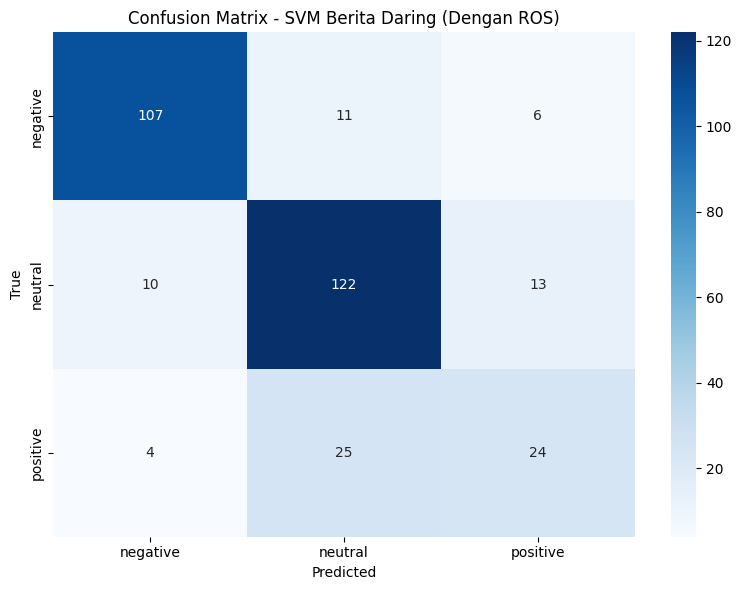

Laporan klasifikasi dan confusion matrix model berita daring dengan ROS berhasil disimpan dan ditampilkan.


In [681]:
report_ros_news = classification_report(
    test_df_news[LABEL_COLUMN],
    test_preds_ros_news,
    output_dict=True,
    zero_division=0
)

pd.DataFrame(report_ros_news).transpose().to_csv(
    os.path.join(ROS_OUTPUT_DIR_NEWS,"classification_report_test_ros.csv")
)

save_confusion_matrix(
    test_df_news[LABEL_COLUMN],
    test_preds_ros_news,
    os.path.join(ROS_OUTPUT_DIR_NEWS,"confusion_matrix_test_ros.png"),
    "Confusion Matrix - SVM Berita Daring (Dengan ROS)"
)
print("Laporan klasifikasi dan confusion matrix model berita daring dengan ROS berhasil disimpan dan ditampilkan.")

### Tanpa Random OverSampler (NO ROS) pada Dataset Berita Daring

In [682]:
print('Distribusi label data pelatihan berita daring (tanpa ROS):')
train_df_news[LABEL_COLUMN].value_counts().sort_index().to_csv(
    os.path.join(NO_ROS_OUTPUT_DIR_NEWS,"train_label_distribution.csv")
)
display(train_df_news[LABEL_COLUMN].value_counts().sort_index().to_frame())

Distribusi label data pelatihan berita daring (tanpa ROS):


,count
sentiment,
negative,498
neutral,578
positive,210


### Cross-Validation Tanpa ROS pada Dataset Berita Daring

In [683]:
cv_df_no_ros_news = train_df_news.reset_index(drop=True)

skf_no_ros_news = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

fold_rows_no_ros_news = []

for fold,(tr_idx,val_idx) in enumerate(
    skf_no_ros_news.split(cv_df_no_ros_news[TEXT_COLUMN],cv_df_no_ros_news[LABEL_COLUMN]),start=1
):

    fold_train_no_ros_news = cv_df_no_ros_news.iloc[tr_idx]
    fold_val_no_ros_news = cv_df_no_ros_news.iloc[val_idx]

    model_no_ros_news = build_svm_pipeline(SVM_CONFIG)

    model_no_ros_news.fit(
        fold_train_no_ros_news[TEXT_COLUMN],
        fold_train_no_ros_news[LABEL_COLUMN]
    )

    preds_no_ros_news = model_no_ros_news.predict(
        fold_val_no_ros_news[TEXT_COLUMN]
    )

    acc_no_ros_news = accuracy_score(fold_val_no_ros_news[LABEL_COLUMN],preds_no_ros_news)
    mf1_no_ros_news = f1_score(fold_val_no_ros_news[LABEL_COLUMN],preds_no_ros_news,average="macro")
    mpre_no_ros_news = precision_score(fold_val_no_ros_news[LABEL_COLUMN],preds_no_ros_news,average="macro",zero_division=0)
    mrec_no_ros_news = recall_score(fold_val_no_ros_news[LABEL_COLUMN],preds_no_ros_news,average="macro",zero_division=0)

    fold_rows_no_ros_news.append({
        "Fold":fold,
        "Accuracy":acc_no_ros_news,
        "Macro_F1":mf1_no_ros_news,
        "Macro_Precision":mpre_no_ros_news,
        "Macro_Recall":mrec_no_ros_news
    })

    report_no_ros_news = classification_report(
        fold_val_no_ros_news[LABEL_COLUMN],
        preds_no_ros_news,
        output_dict=True,
        zero_division=0
    )

    pd.DataFrame(report_no_ros_news).transpose().to_csv(
        os.path.join(
            NO_ROS_OUTPUT_DIR_NEWS,
            f"fold_{fold}_classification_report_no_ros.csv"
        )
    )

fold_df_no_ros_news = pd.DataFrame(fold_rows_no_ros_news)

mean_row_no_ros_news = pd.DataFrame([
    {
        "Fold":"Mean",
        "Accuracy":fold_df_no_ros_news["Accuracy"].mean(),
        "Macro_F1":fold_df_no_ros_news["Macro_F1"].mean(),
        "Macro_Precision":fold_df_no_ros_news["Macro_Precision"].mean(),
        "Macro_Recall":fold_df_no_ros_news["Macro_Recall"].mean()
    }
])

cv_folds_no_ros_news = pd.concat([fold_df_no_ros_news,mean_row_no_ros_news],ignore_index=True)

cv_folds_no_ros_news.to_csv(
    os.path.join(NO_ROS_OUTPUT_DIR_NEWS,"cv_folds_no_ros.csv"),
    index=False
)

summary_df_no_ros_news = pd.DataFrame([
    {
        "Model":"SVM",
        "Mean_Accuracy":fold_df_no_ros_news["Accuracy"].mean(),
        "Mean_Macro_F1":fold_df_no_ros_news["Macro_F1"].mean(),
        "Mean_Macro_Precision":fold_df_no_ros_news["Macro_Precision"].mean(),
        "Mean_Macro_Recall":fold_df_no_ros_news["Macro_Recall"].mean(),
        "Std_Accuracy":fold_df_no_ros_news["Accuracy"].std(),
        "Std_Macro_F1":fold_df_no_ros_news["Macro_F1"].std()
    }
])

summary_df_no_ros_news.to_csv(
    os.path.join(NO_ROS_OUTPUT_DIR_NEWS,"cv_summary_no_ros.csv"),
    index=False
)

print("Hasil Cross-Validation Tanpa ROS untuk Berita Daring:")
display(cv_folds_no_ros_news)
display(summary_df_no_ros_news)

Hasil Cross-Validation Tanpa ROS untuk Berita Daring:


,Fold,Accuracy,Macro_F1,Macro_Precision,Macro_Recall
0,1,0.763566,0.699032,0.712674,0.693541
1,2,0.789883,0.730927,0.771456,0.714435
2,3,0.766537,0.722271,0.727786,0.717939
3,4,0.762646,0.695444,0.721956,0.685680
4,5,0.789883,0.727272,0.735201,0.722388
5,Mean,0.774503,0.714989,0.733815,0.706797


,Model,Mean_Accuracy,Mean_Macro_F1,Mean_Macro_Precision,Mean_Macro_Recall,Std_Accuracy,Std_Macro_F1
0,SVM,0.774503,0.714989,0.733815,0.706797,0.014114,0.016542


### Pelatihan Model Akhir Tanpa ROS pada Dataset Berita Daring

In [684]:
final_model_no_ros_news = build_svm_pipeline(SVM_CONFIG)

final_model_no_ros_news.fit(
    train_df_news[TEXT_COLUMN],
    train_df_news[LABEL_COLUMN]
)

joblib.dump(
    final_model_no_ros_news,
    os.path.join(NO_ROS_OUTPUT_DIR_NEWS,"svm_model_no_ros.joblib")
)
print('Model akhir berita daring tanpa ROS berhasil dilatih dan disimpan.')

Model akhir berita daring tanpa ROS berhasil dilatih dan disimpan.


### Evaluasi Model Akhir Tanpa ROS pada Data Uji Berita Daring

In [685]:
test_preds_no_ros_news = final_model_no_ros_news.predict(
    test_df_news[TEXT_COLUMN]
)

test_acc_no_ros_news = accuracy_score(test_df_news[LABEL_COLUMN],test_preds_no_ros_news)
test_f1_no_ros_news = f1_score(test_df_news[LABEL_COLUMN],test_preds_no_ros_news,average="macro")
test_prec_no_ros_news = precision_score(test_df_news[LABEL_COLUMN],test_preds_no_ros_news,average="macro",zero_division=0)
test_rec_no_ros_news = recall_score(test_df_news[LABEL_COLUMN],test_preds_no_ros_news,average="macro",zero_division=0)

final_metrics_no_ros_news = pd.DataFrame([
    {
        "Accuracy":test_acc_no_ros_news,
        "Macro_F1":test_f1_no_ros_news,
        "Macro_Precision":test_prec_no_ros_news,
        "Macro_Recall":test_rec_no_ros_news
    }
])

final_metrics_no_ros_news.to_csv(
    os.path.join(NO_ROS_OUTPUT_DIR_NEWS,"final_test_metrics_no_ros.csv"),
    index=False
)

print("Metrik Evaluasi Model Akhir Tanpa ROS untuk Berita Daring:")
display(final_metrics_no_ros_news)

Metrik Evaluasi Model Akhir Tanpa ROS untuk Berita Daring:


,Accuracy,Macro_F1,Macro_Precision,Macro_Recall
0,0.791925,0.738238,0.748042,0.731616


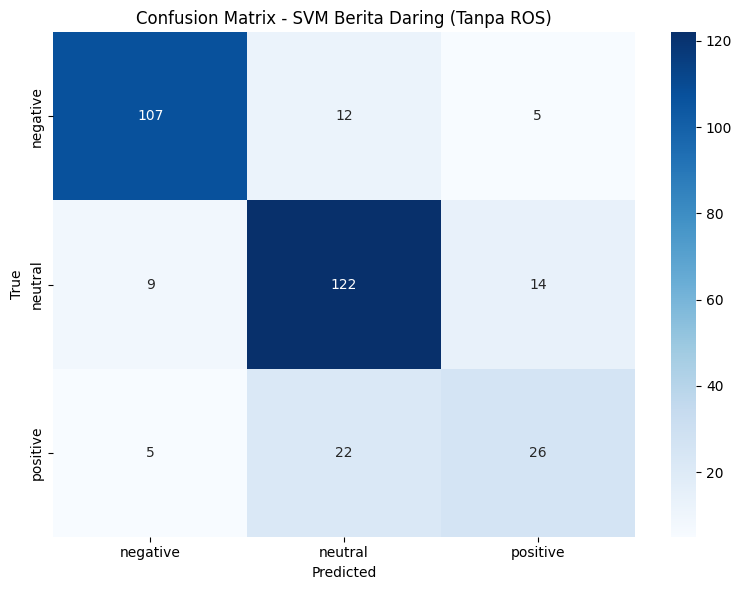

Laporan klasifikasi dan confusion matrix model berita daring tanpa ROS berhasil disimpan dan ditampilkan.


In [686]:
report_no_ros_news = classification_report(
    test_df_news[LABEL_COLUMN],
    test_preds_no_ros_news,
    output_dict=True,
    zero_division=0
)

pd.DataFrame(report_no_ros_news).transpose().to_csv(
    os.path.join(NO_ROS_OUTPUT_DIR_NEWS,"classification_report_test_no_ros.csv")
)

save_confusion_matrix(
    test_df_news[LABEL_COLUMN],
    test_preds_no_ros_news,
    os.path.join(NO_ROS_OUTPUT_DIR_NEWS,"confusion_matrix_test_no_ros.png"),
    "Confusion Matrix - SVM Berita Daring (Tanpa ROS)"
)
print("Laporan klasifikasi dan confusion matrix model berita daring tanpa ROS berhasil disimpan dan ditampilkan.")

### Perbandingan Hasil: Dengan ROS vs Tanpa ROS pada Dataset Berita Daring

Perbandingan Hasil Cross-Validation Berita Daring (Rata-rata):


,Model,Mean_Accuracy,Mean_Macro_F1,Mean_Macro_Precision,Mean_Macro_Recall,Std_Accuracy,Std_Macro_F1,Scenario
0,SVM,0.773725,0.709442,0.732772,0.700511,0.013965,0.014007,With ROS
1,SVM,0.774503,0.714989,0.733815,0.706797,0.014114,0.016542,Without ROS


Perbandingan Metrik Uji Akhir Berita Daring:


,Accuracy,Macro_F1,Macro_Precision,Macro_Recall,Scenario
0,0.785714,0.726250,0.738196,0.719038,With ROS
1,0.791925,0.738238,0.748042,0.731616,Without ROS


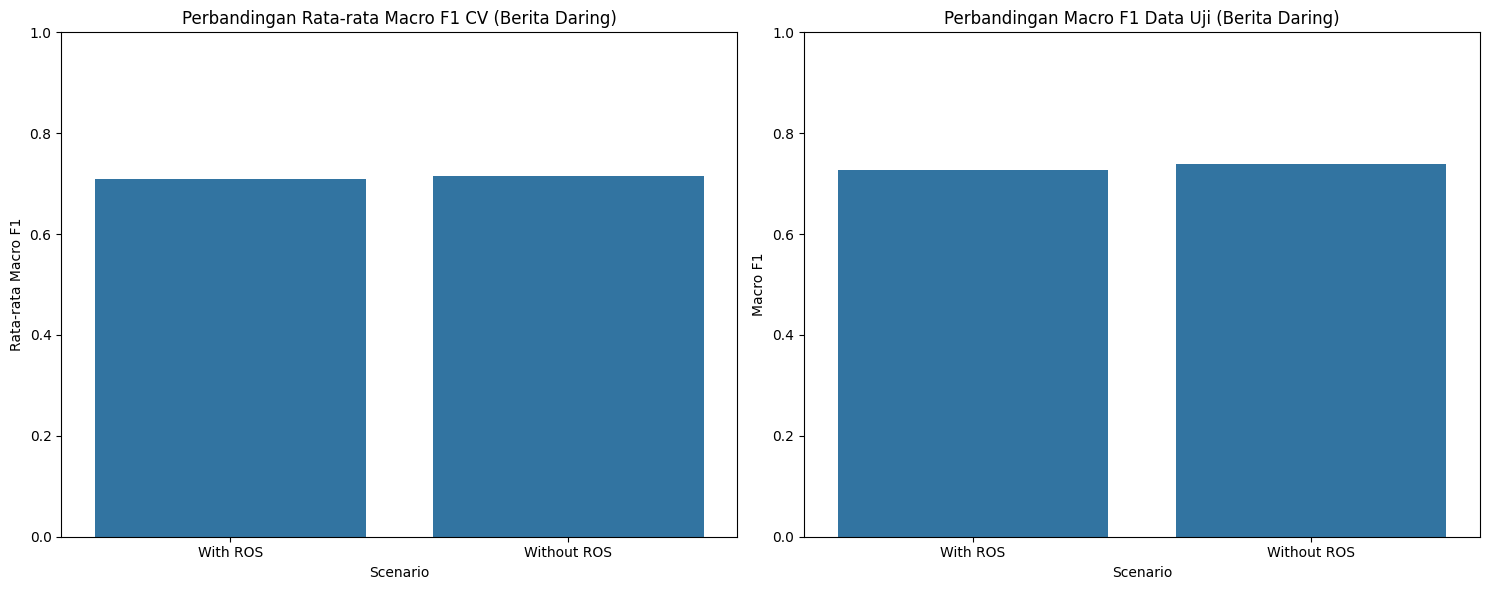

In [687]:
# Load summary CV results for news dataset
summary_ros_news = pd.read_csv(os.path.join(ROS_OUTPUT_DIR_NEWS, "cv_summary.csv"))
summary_ros_news['Scenario'] = 'With ROS'

summary_no_ros_news = pd.read_csv(os.path.join(NO_ROS_OUTPUT_DIR_NEWS, "cv_summary_no_ros.csv"))
summary_no_ros_news['Scenario'] = 'Without ROS'

comparison_cv_summary_news = pd.concat([summary_ros_news, summary_no_ros_news], ignore_index=True)
print("Perbandingan Hasil Cross-Validation Berita Daring (Rata-rata):")
display(comparison_cv_summary_news)

# Load final test metrics for news dataset
metrics_ros_news = pd.read_csv(os.path.join(ROS_OUTPUT_DIR_NEWS, "final_test_metrics_ros.csv"))
metrics_ros_news['Scenario'] = 'With ROS'

metrics_no_ros_news = pd.read_csv(os.path.join(NO_ROS_OUTPUT_DIR_NEWS, "final_test_metrics_no_ros.csv"))
metrics_no_ros_news['Scenario'] = 'Without ROS'

comparison_test_metrics_news = pd.concat([metrics_ros_news, metrics_no_ros_news], ignore_index=True)
print("Perbandingan Metrik Uji Akhir Berita Daring:")
display(comparison_test_metrics_news)

# Visualize comparison for news dataset
fig_news, axes_news = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x='Scenario', y='Mean_Macro_F1', data=comparison_cv_summary_news, ax=axes_news[0])
axes_news[0].set_title('Perbandingan Rata-rata Macro F1 CV (Berita Daring)')
axes_news[0].set_ylabel('Rata-rata Macro F1')
axes_news[0].set_ylim(0, 1) # Set y-axis limit to 0-1 for scores

sns.barplot(x='Scenario', y='Macro_F1', data=comparison_test_metrics_news, ax=axes_news[1])
axes_news[1].set_title('Perbandingan Macro F1 Data Uji (Berita Daring)')
axes_news[1].set_ylabel('Macro F1')
axes_news[1].set_ylim(0, 1) # Set y-axis limit to 0-1 for scores

plt.tight_layout()
plt.show()

Perbandingan Hasil Cross-Validation (Rata-rata):


,Model,Mean_Accuracy,Mean_Macro_F1,Mean_Macro_Precision,Mean_Macro_Recall,Std_Accuracy,Std_Macro_F1,Scenario
0,SVM,0.762897,0.753718,0.750626,0.759148,0.011605,0.011903,With ROS
1,SVM,0.763244,0.756389,0.749237,0.767391,0.010579,0.009722,Without ROS


Perbandingan Metrik Uji Akhir:


,Accuracy,Macro_F1,Macro_Precision,Macro_Recall,Scenario
0,0.772664,0.768304,0.762419,0.777065,With ROS
1,0.764296,0.759761,0.751783,0.771082,Without ROS


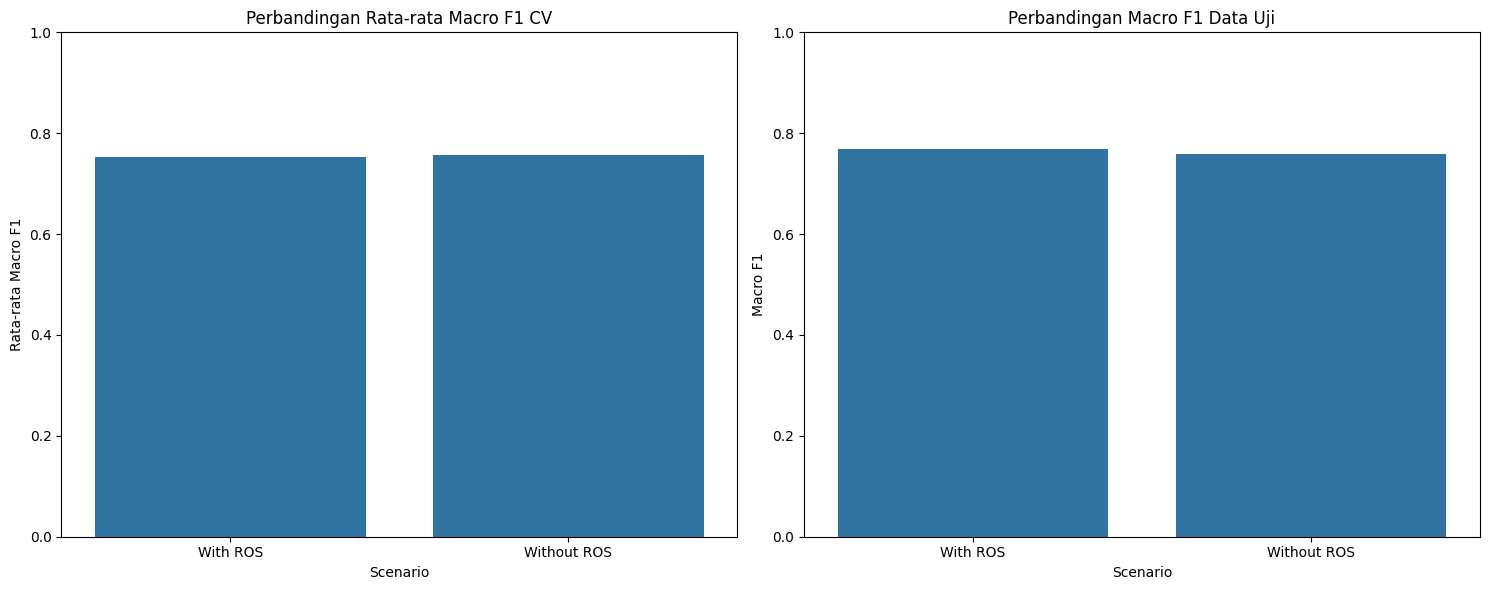

In [688]:
# Load summary CV results
summary_ros = pd.read_csv(os.path.join(ROS_OUTPUT_DIR, "cv_summary.csv"))
summary_ros['Scenario'] = 'With ROS'

summary_no_ros = pd.read_csv(os.path.join(NO_ROS_OUTPUT_DIR, "cv_summary_no_ros.csv"))
summary_no_ros['Scenario'] = 'Without ROS'

comparison_cv_summary = pd.concat([summary_ros, summary_no_ros], ignore_index=True)
print("Perbandingan Hasil Cross-Validation (Rata-rata):")
display(comparison_cv_summary)

# Load final test metrics
metrics_ros = pd.read_csv(os.path.join(ROS_OUTPUT_DIR, "final_test_metrics_ros.csv"))
metrics_ros['Scenario'] = 'With ROS'

metrics_no_ros = pd.read_csv(os.path.join(NO_ROS_OUTPUT_DIR, "final_test_metrics_no_ros.csv"))
metrics_no_ros['Scenario'] = 'Without ROS'

comparison_test_metrics = pd.concat([metrics_ros, metrics_no_ros], ignore_index=True)
print("Perbandingan Metrik Uji Akhir:")
display(comparison_test_metrics)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x='Scenario', y='Mean_Macro_F1', data=comparison_cv_summary, ax=axes[0])
axes[0].set_title('Perbandingan Rata-rata Macro F1 CV')
axes[0].set_ylabel('Rata-rata Macro F1')
axes[0].set_ylim(0, 1) # Set y-axis limit to 0-1 for scores

sns.barplot(x='Scenario', y='Macro_F1', data=comparison_test_metrics, ax=axes[1])
axes[1].set_title('Perbandingan Macro F1 Data Uji')
axes[1].set_ylabel('Macro F1')
axes[1].set_ylim(0, 1) # Set y-axis limit to 0-1 for scores

plt.tight_layout()
plt.show()

In [689]:
summary_ros['Dataset'] = 'Sosmed'
summary_no_ros['Dataset'] = 'Sosmed'
summary_ros_news['Dataset'] = 'Berita Daring'
summary_no_ros_news['Dataset'] = 'Berita Daring'

combined_cv_summary = pd.concat([summary_ros, summary_no_ros, summary_ros_news, summary_no_ros_news], ignore_index=True)

# Reorder columns for better readability
combined_cv_summary = combined_cv_summary[['Dataset', 'Scenario', 'Mean_Accuracy', 'Mean_Macro_F1', 'Mean_Macro_Precision', 'Mean_Macro_Recall', 'Std_Accuracy', 'Std_Macro_F1']]

display(combined_cv_summary)

,Dataset,Scenario,Mean_Accuracy,Mean_Macro_F1,Mean_Macro_Precision,Mean_Macro_Recall,Std_Accuracy,Std_Macro_F1
0,Sosmed,With ROS,0.762897,0.753718,0.750626,0.759148,0.011605,0.011903
1,Sosmed,Without ROS,0.763244,0.756389,0.749237,0.767391,0.010579,0.009722
2,Berita Daring,With ROS,0.773725,0.709442,0.732772,0.700511,0.013965,0.014007
3,Berita Daring,Without ROS,0.774503,0.714989,0.733815,0.706797,0.014114,0.016542


In [690]:
vectorizer_sosmed = TfidfVectorizer(
    max_features=SVM_CONFIG["max_features"],
    ngram_range=SVM_CONFIG["ngram_range"],
    min_df=SVM_CONFIG["min_df"],
    max_df=SVM_CONFIG["max_df"],
    sublinear_tf=SVM_CONFIG["sublinear_tf"]
)
X_sosmed = vectorizer_sosmed.fit_transform(train_df[TEXT_COLUMN])
print(f"Number of features (Sosmed dataset): {len(vectorizer_sosmed.get_feature_names_out())}")

vectorizer_news = TfidfVectorizer(
    max_features=SVM_CONFIG["max_features"],
    ngram_range=SVM_CONFIG["ngram_range"],
    min_df=SVM_CONFIG["min_df"],
    max_df=SVM_CONFIG["max_df"],
    sublinear_tf=SVM_CONFIG["sublinear_tf"]
)
X_news = vectorizer_news.fit_transform(train_df_news[TEXT_COLUMN])
print(f"Number of features (Berita Daring dataset): {len(vectorizer_news.get_feature_names_out())}")

Number of features (Sosmed dataset): 5606
Number of features (Berita Daring dataset): 20000


## Eksperimen Parameter SVM

Untuk melakukan eksperimen dengan berbagai kombinasi parameter `C`, `min_df`, dan `class_weight`, kita akan menggunakan fungsi pembantu untuk menjalankan satu skenario pelatihan dan evaluasi. Fungsi ini akan mengembalikan metrik _cross-validation_ dan metrik pengujian akhir untuk setiap kombinasi parameter dan setiap dataset (dengan/tanpa ROS).

In [697]:
import os, json, joblib, random, warnings
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
from imblearn.over_sampling import RandomOverSampler

warnings.filterwarnings("ignore")

# Memastikan fungsi build_svm_pipeline tersedia (dari cell 05BFkEEfKaZY)
# Jika cell 05BFkEEfKaZY tidak dijalankan, pastikan untuk menjalankannya terlebih dahulu.
# Fungsi build_svm_pipeline didefinisikan secara global di notebook ini.

def run_single_scenario_experiment(
    train_df_input, # Data training asli untuk splitting CV
    test_df_input, # Data testing asli
    text_column,
    label_column,
    svm_config_current, # Konfigurasi SVM untuk eksperimen saat ini
    random_state,
    run_ros=False,
    dataset_name="Sosmed", # Untuk identifikasi output
    scenario_name="With ROS" # Untuk identifikasi output
):
    print(f"\nRunning experiment for {dataset_name} - {scenario_name} with C={svm_config_current['C']}, min_df={svm_config_current['min_df']}, class_weight={svm_config_current['class_weight']}")

    # Persiapkan data training untuk model akhir (bisa di-oversample)
    train_df_final_model = train_df_input.copy()

    if run_ros:
        ros = RandomOverSampler(random_state=random_state)
        X_train_resampled, y_train_resampled = ros.fit_resample(
            train_df_final_model[text_column].values.reshape(-1, 1),
            train_df_final_model[label_column]
        )
        train_df_final_model = pd.DataFrame({text_column: X_train_resampled.flatten(), label_column: y_train_resampled})

    # Cross-Validation
    # Gunakan train_df_input asli untuk membagi fold CV agar tidak terjadi data leakage
    cv_df = train_df_input.reset_index(drop=True)

    skf = StratifiedKFold(
        n_splits=svm_config_current["n_splits"],
        shuffle=True,
        random_state=random_state
    )

    fold_rows = []
    for fold, (tr_idx, val_idx) in enumerate(skf.split(cv_df[text_column], cv_df[label_column]), start=1):
        fold_train = cv_df.iloc[tr_idx]
        fold_val = cv_df.iloc[val_idx]

        X_fit_cv = fold_train[text_column]
        y_fit_cv = fold_train[label_column]

        # Aplikasikan ROS HANYA pada bagian training dari fold saat ini untuk CV
        if run_ros:
            ros_fold = RandomOverSampler(random_state=random_state)
            X_fold_train_resampled, y_fold_train_resampled = ros_fold.fit_resample(
                fold_train[text_column].values.reshape(-1, 1),
                fold_train[label_column]
            )
            X_fit_cv = X_fold_train_resampled.flatten()
            y_fit_cv = y_fold_train_resampled

        model = build_svm_pipeline(svm_config_current) # Pastikan build_svm_pipeline dapat diakses
        model.fit(X_fit_cv, y_fit_cv)
        preds = model.predict(fold_val[text_column])

        acc = accuracy_score(fold_val[label_column], preds)
        mf1 = f1_score(fold_val[label_column], preds, average="macro")
        mpre = precision_score(fold_val[label_column], preds, average="macro", zero_division=0)
        mrec = recall_score(fold_val[label_column], preds, average="macro", zero_division=0)

        fold_rows.append({
            "Fold": fold,
            "Accuracy": acc,
            "Macro_F1": mf1,
            "Macro_Precision": mpre,
            "Macro_Recall": mrec
        })

    fold_df = pd.DataFrame(fold_rows)
    summary_cv_result = pd.DataFrame([
        {
            "Model": "SVM",
            "Mean_Accuracy": fold_df["Accuracy"].mean(),
            "Mean_Macro_F1": fold_df["Macro_F1"].mean(),
            "Mean_Macro_Precision": fold_df["Macro_Precision"].mean(),
            "Mean_Macro_Recall": fold_df["Macro_Recall"].mean(),
            "Std_Accuracy": fold_df["Accuracy"].std(),
            "Std_Macro_F1": fold_df["Macro_F1"].std()
        }
    ])

    # Pelatihan Model Akhir dan Evaluasi pada Test Set
    final_model = build_svm_pipeline(svm_config_current)
    final_model.fit(
        train_df_final_model[text_column], # Gunakan data training yang sudah diproses (potensi oversampled)
        train_df_final_model[label_column]
    )

    test_preds = final_model.predict(test_df_input[text_column])
    test_acc = accuracy_score(test_df_input[label_column], test_preds)
    test_f1 = f1_score(test_df_input[label_column], test_preds, average="macro")
    test_prec = precision_score(test_df_input[label_column], test_preds, average="macro", zero_division=0)
    test_rec = recall_score(test_df_input[label_column], test_preds, average="macro", zero_division=0)

    final_metrics_result = pd.DataFrame([
        {
            "Accuracy": test_acc,
            "Macro_F1": test_f1,
            "Macro_Precision": test_prec,
            "Macro_Recall": test_rec
        }
    ])

    return summary_cv_result, final_metrics_result, test_preds

In [692]:
# Definisikan grid parameter untuk eksperimen
C_values = [0.5, 1, 2]
min_df_values = [2, 3]
class_weight_values = [None, "balanced"]

all_experiment_results = []

# Ambil konfigurasi SVM dasar dari SVM_CONFIG yang sudah ada (cell 05BFkEEfKaZY)
# Buat salinan agar tidak memodifikasi objek global secara langsung
base_svm_config = SVM_CONFIG.copy()

for c_val in C_values:
    for min_d_val in min_df_values:
        for cw_val in class_weight_values:
            current_svm_config = base_svm_config.copy()
            current_svm_config["C"] = c_val
            current_svm_config["min_df"] = min_d_val
            current_svm_config["class_weight"] = cw_val

            # --- Eksperimen untuk Dataset Sosmed (Dengan ROS) ---
            summary_cv_ros_sosmed, final_metrics_ros_sosmed = run_single_scenario_experiment(
                train_df, # train_df dari Sosmed
                test_df, # test_df dari Sosmed
                TEXT_COLUMN,
                LABEL_COLUMN,
                current_svm_config,
                RANDOM_STATE,
                run_ros=True,
                dataset_name="Sosmed",
                scenario_name="With ROS"
            )
            all_experiment_results.append({
                "Dataset": "Sosmed",
                "Scenario": "With ROS",
                "C": c_val,
                "min_df": min_d_val,
                "class_weight": cw_val,
                "Mean_Accuracy_CV": summary_cv_ros_sosmed["Mean_Accuracy"].iloc[0],
                "Mean_Macro_F1_CV": summary_cv_ros_sosmed["Mean_Macro_F1"].iloc[0],
                "Macro_F1_Test": final_metrics_ros_sosmed["Macro_F1"].iloc[0]
            })

            # --- Eksperimen untuk Dataset Sosmed (Tanpa ROS) ---
            summary_cv_no_ros_sosmed, final_metrics_no_ros_sosmed = run_single_scenario_experiment(
                train_df, # train_df dari Sosmed
                test_df, # test_df dari Sosmed
                TEXT_COLUMN,
                LABEL_COLUMN,
                current_svm_config,
                RANDOM_STATE,
                run_ros=False,
                dataset_name="Sosmed",
                scenario_name="Without ROS"
            )
            all_experiment_results.append({
                "Dataset": "Sosmed",
                "Scenario": "Without ROS",
                "C": c_val,
                "min_df": min_d_val,
                "class_weight": cw_val,
                "Mean_Accuracy_CV": summary_cv_no_ros_sosmed["Mean_Accuracy"].iloc[0],
                "Mean_Macro_F1_CV": summary_cv_no_ros_sosmed["Mean_Macro_F1"].iloc[0],
                "Macro_F1_Test": final_metrics_no_ros_sosmed["Macro_F1"].iloc[0]
            })

            # --- Eksperimen untuk Dataset Berita Daring (Dengan ROS) ---
            summary_cv_ros_news, final_metrics_ros_news = run_single_scenario_experiment(
                train_df_news, # train_df dari Berita Daring
                test_df_news, # test_df dari Berita Daring
                TEXT_COLUMN,
                LABEL_COLUMN,
                current_svm_config,
                RANDOM_STATE,
                run_ros=True,
                dataset_name="Berita Daring",
                scenario_name="With ROS"
            )
            all_experiment_results.append({
                "Dataset": "Berita Daring",
                "Scenario": "With ROS",
                "C": c_val,
                "min_df": min_d_val,
                "class_weight": cw_val,
                "Mean_Accuracy_CV": summary_cv_ros_news["Mean_Accuracy"].iloc[0],
                "Mean_Macro_F1_CV": summary_cv_ros_news["Mean_Macro_F1"].iloc[0],
                "Macro_F1_Test": final_metrics_ros_news["Macro_F1"].iloc[0]
            })

            # --- Eksperimen untuk Dataset Berita Daring (Tanpa ROS) ---
            summary_cv_no_ros_news, final_metrics_no_ros_news = run_single_scenario_experiment(
                train_df_news, # train_df dari Berita Daring
                test_df_news, # test_df dari Berita Daring
                TEXT_COLUMN,
                LABEL_COLUMN,
                current_svm_config,
                RANDOM_STATE,
                run_ros=False,
                dataset_name="Berita Daring",
                scenario_name="Without ROS"
            )
            all_experiment_results.append({
                "Dataset": "Berita Daring",
                "Scenario": "Without ROS",
                "C": c_val,
                "min_df": min_d_val,
                "class_weight": cw_val,
                "Mean_Accuracy_CV": summary_cv_no_ros_news["Mean_Accuracy"].iloc[0],
                "Mean_Macro_F1_CV": summary_cv_no_ros_news["Mean_Macro_F1"].iloc[0],
                "Macro_F1_Test": final_metrics_no_ros_news["Macro_F1"].iloc[0]
            })

# Konversi hasil ke DataFrame untuk tampilan yang rapi
comparison_table = pd.DataFrame(all_experiment_results)

print("\n--- Tabel Perbandingan Keseluruhan Hasil Eksperimen ---")
display(comparison_table.sort_values(by=["Dataset", "Scenario", "Macro_F1_Test"], ascending=[True, True, False]))


Running experiment for Sosmed - With ROS with C=0.5, min_df=2, class_weight=None

Running experiment for Sosmed - Without ROS with C=0.5, min_df=2, class_weight=None

Running experiment for Berita Daring - With ROS with C=0.5, min_df=2, class_weight=None

Running experiment for Berita Daring - Without ROS with C=0.5, min_df=2, class_weight=None

Running experiment for Sosmed - With ROS with C=0.5, min_df=2, class_weight=balanced

Running experiment for Sosmed - Without ROS with C=0.5, min_df=2, class_weight=balanced

Running experiment for Berita Daring - With ROS with C=0.5, min_df=2, class_weight=balanced

Running experiment for Berita Daring - Without ROS with C=0.5, min_df=2, class_weight=balanced

Running experiment for Sosmed - With ROS with C=0.5, min_df=3, class_weight=None

Running experiment for Sosmed - Without ROS with C=0.5, min_df=3, class_weight=None

Running experiment for Berita Daring - With ROS with C=0.5, min_df=3, class_weight=None

Running experiment for Berita D

,Dataset,Scenario,C,min_df,class_weight,Mean_Accuracy_CV,Mean_Macro_F1_CV,Macro_F1_Test
2,Berita Daring,With ROS,0.5,2,None,0.772178,0.711191,0.731133
6,Berita Daring,With ROS,0.5,2,balanced,0.772178,0.711191,0.731133
10,Berita Daring,With ROS,0.5,3,None,0.772172,0.713033,0.730636
14,Berita Daring,With ROS,0.5,3,balanced,0.772172,0.713033,0.730636
26,Berita Daring,With ROS,1.0,3,None,0.772196,0.707444,0.726250
30,Berita Daring,With ROS,1.0,3,balanced,0.772196,0.707444,0.726250
18,Berita Daring,With ROS,1.0,2,None,0.776078,0.714289,0.723245
22,Berita Daring,With ROS,1.0,2,balanced,0.776078,0.714289,0.723245
42,Berita Daring,With ROS,2.0,3,None,0.772190,0.707545,0.699480
46,Berita Daring,With ROS,2.0,3,balanced,0.772190,0.707545,0.699480


## Final Training Configuration - Dataset Media Sosial

--- Dataset Media Sosial: Scenario = With ROS ---

Running experiment for Sosmed - With ROS with C=0.5, min_df=3, class_weight=None

Hasil Cross-Validation Per-Fold (K=5) untuk Sosmed (With ROS):


,Fold,Accuracy,Macro_F1,Macro_Precision,Macro_Recall
0,1,0.789199,0.778427,0.774213,0.789517
1,2,0.764808,0.760327,0.750399,0.774559
2,3,0.757840,0.752817,0.749429,0.757776
3,4,0.755672,0.743395,0.736333,0.753307
4,5,0.771379,0.762531,0.755763,0.772489



Rata-rata Hasil Cross-Validation (K=5) untuk Sosmed (With ROS):


,Model,Mean_Accuracy,Mean_Macro_F1,Mean_Macro_Precision,Mean_Macro_Recall,Std_Accuracy,Std_Macro_F1
0,SVM,0.767779,0.759499,0.753227,0.76953,0.013472,0.012963



Metrik Uji Akhir untuk Sosmed (With ROS):


,Accuracy,Macro_F1,Macro_Precision,Macro_Recall
0,0.774059,0.768429,0.759975,0.782033


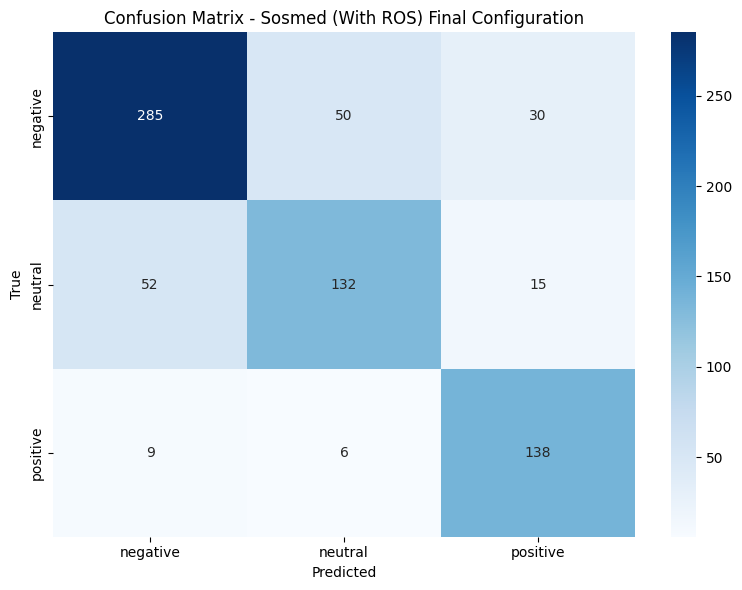

In [699]:
print("--- Dataset Media Sosial: Scenario = With ROS ---")

# Configure SVM parameters for Sosmed (With ROS)
final_svm_config_sosmed = base_svm_config.copy()
final_svm_config_sosmed["C"] = 0.5
final_svm_config_sosmed["min_df"] = 3
final_svm_config_sosmed["class_weight"] = None
final_svm_config_sosmed["n_splits"] = 5 # As specified in the prompt (k=5)

# Run experiment for Sosmed (With ROS) to get summary, final test metrics, and test predictions
summary_cv_sosmed_final, final_metrics_sosmed_final, final_preds_sosmed = run_single_scenario_experiment(
    train_df,
    test_df,
    TEXT_COLUMN,
    LABEL_COLUMN,
    final_svm_config_sosmed,
    RANDOM_STATE,
    run_ros=True,
    dataset_name="Sosmed",
    scenario_name="With ROS"
)

# --- Code to generate and display per-fold results (unchanged) ---
print("\nHasil Cross-Validation Per-Fold (K=5) untuk Sosmed (With ROS):")

# Re-run the CV part specifically to get the fold_df for display
cv_df_for_display = train_df.reset_index(drop=True) # Use original train_df for splitting CV

skf_for_display = StratifiedKFold(
    n_splits=final_svm_config_sosmed["n_splits"],
    shuffle=True,
    random_state=RANDOM_STATE
)

fold_rows_for_display = []
for fold, (tr_idx, val_idx) in enumerate(skf_for_display.split(cv_df_for_display[TEXT_COLUMN], cv_df_for_display[LABEL_COLUMN]), start=1):
    fold_train_for_display = cv_df_for_display.iloc[tr_idx]
    fold_val_for_display = cv_df_for_display.iloc[val_idx]

    X_fit_cv_for_display = fold_train_for_display[TEXT_COLUMN]
    y_fit_cv_for_display = fold_train_for_display[LABEL_COLUMN]

    # Apply ROS ONLY to the training part of the current fold for CV (run_ros is True for this scenario)
    ros_fold_for_display = RandomOverSampler(random_state=RANDOM_STATE)
    X_fold_train_resampled_for_display, y_fold_train_resampled_for_display = ros_fold_for_display.fit_resample(
        fold_train_for_display[TEXT_COLUMN].values.reshape(-1, 1),
        fold_train_for_display[LABEL_COLUMN]
    )
    X_fit_cv_for_display = X_fold_train_resampled_for_display.flatten()
    y_fit_cv_for_display = y_fold_train_resampled_for_display

    model_for_display = build_svm_pipeline(final_svm_config_sosmed) # build_svm_pipeline is globally defined
    model_for_display.fit(X_fit_cv_for_display, y_fit_cv_for_display)
    preds_for_display = model_for_display.predict(fold_val_for_display[TEXT_COLUMN])

    acc_for_display = accuracy_score(fold_val_for_display[LABEL_COLUMN], preds_for_display)
    mf1_for_display = f1_score(fold_val_for_display[LABEL_COLUMN], preds_for_display, average="macro")
    mpre_for_display = precision_score(fold_val_for_display[LABEL_COLUMN], preds_for_display, average="macro", zero_division=0)
    mrec_for_display = recall_score(fold_val_for_display[LABEL_COLUMN], preds_for_display, average="macro", zero_division=0)

    fold_rows_for_display.append({
        "Fold": fold,
        "Accuracy": acc_for_display,
        "Macro_F1": mf1_for_display,
        "Macro_Precision": mpre_for_display,
        "Macro_Recall": mrec_for_display
    })

fold_df_for_display = pd.DataFrame(fold_rows_for_display)
display(fold_df_for_display)

print("\nRata-rata Hasil Cross-Validation (K=5) untuk Sosmed (With ROS):")
display(summary_cv_sosmed_final)
print("\nMetrik Uji Akhir untuk Sosmed (With ROS):")
display(final_metrics_sosmed_final)

# Add Confusion Matrix display
save_confusion_matrix(
    test_df[LABEL_COLUMN],
    final_preds_sosmed,
    os.path.join(ROS_OUTPUT_DIR, "confusion_matrix_final_sosmed_ros.png"),
    "Confusion Matrix - Sosmed (With ROS) Final Configuration"
)

## Final Training Configuration - Dataset Berita Daring


--- Dataset Berita Daring: Scenario = Without ROS ---

Running experiment for Berita Daring - Without ROS with C=0.5, min_df=3, class_weight=balanced

Hasil Cross-Validation Per-Fold (K=5) untuk Berita Daring (Without ROS):


,Fold,Accuracy,Macro_F1,Macro_Precision,Macro_Recall
0,1,0.759690,0.696123,0.710054,0.690208
1,2,0.785992,0.722635,0.765451,0.706498
2,3,0.770428,0.721983,0.729002,0.716736
3,4,0.774319,0.705411,0.736050,0.694810
4,5,0.789883,0.732629,0.741457,0.726991



Rata-rata Hasil Cross-Validation (K=5) untuk Berita Daring (Without ROS):


,Model,Mean_Accuracy,Mean_Macro_F1,Mean_Macro_Precision,Mean_Macro_Recall,Std_Accuracy,Std_Macro_F1
0,SVM,0.776062,0.715756,0.736403,0.707049,0.01217,0.014691



Metrik Uji Akhir untuk Berita Daring (Without ROS):


,Accuracy,Macro_F1,Macro_Precision,Macro_Recall
0,0.795031,0.744909,0.748541,0.741896


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/svm_news/20260723_153556/without_ros/confusion_matrix_final_news_no_ros.png'

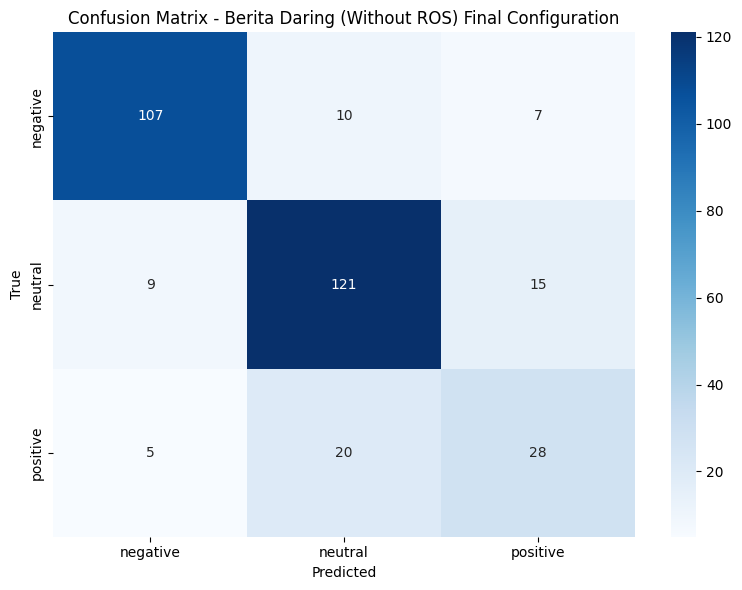

In [702]:
print("\n--- Dataset Berita Daring: Scenario = Without ROS ---")

# Configure SVM parameters for Berita Daring (Without ROS)
final_svm_config_news = base_svm_config.copy()
final_svm_config_news["C"] = 0.5
final_svm_config_news["min_df"] = 3
final_svm_config_news["class_weight"] = "balanced"
final_svm_config_news["n_splits"] = 5 # As specified in the prompt (k=5)

# Run experiment for Berita Daring (Without ROS) to get summary, final test metrics, and test predictions
summary_cv_news_final, final_metrics_news_final, final_preds_news = run_single_scenario_experiment(
    train_df_news,
    test_df_news,
    TEXT_COLUMN,
    LABEL_COLUMN,
    final_svm_config_news,
    RANDOM_STATE,
    run_ros=False,
    dataset_name="Berita Daring",
    scenario_name="Without ROS"
)

# --- Code to generate and display per-fold results (adapted from Sosmed) ---
print("\nHasil Cross-Validation Per-Fold (K=5) untuk Berita Daring (Without ROS):")

# Re-run the CV part specifically to get the fold_df for display
cv_df_for_display_news = train_df_news.reset_index(drop=True) # Use original train_df_news for splitting CV

skf_for_display_news = StratifiedKFold(
    n_splits=final_svm_config_news["n_splits"],
    shuffle=True,
    random_state=RANDOM_STATE
)

fold_rows_for_display_news = []
for fold, (tr_idx, val_idx) in enumerate(skf_for_display_news.split(cv_df_for_display_news[TEXT_COLUMN], cv_df_for_display_news[LABEL_COLUMN]), start=1):
    fold_train_for_display_news = cv_df_for_display_news.iloc[tr_idx]
    fold_val_for_display_news = cv_df_for_display_news.iloc[val_idx]

    X_fit_cv_for_display_news = fold_train_for_display_news[TEXT_COLUMN]
    y_fit_cv_for_display_news = fold_train_for_display_news[LABEL_COLUMN]

    # No ROS applied here for the "Without ROS" scenario
    # if run_ros: # This block will be skipped as run_ros is false

    model_for_display_news = build_svm_pipeline(final_svm_config_news) # build_svm_pipeline is globally defined
    model_for_display_news.fit(X_fit_cv_for_display_news, y_fit_cv_for_display_news)
    preds_for_display_news = model_for_display_news.predict(fold_val_for_display_news[TEXT_COLUMN])

    acc_for_display_news = accuracy_score(fold_val_for_display_news[LABEL_COLUMN], preds_for_display_news)
    mf1_for_display_news = f1_score(fold_val_for_display_news[LABEL_COLUMN], preds_for_display_news, average="macro")
    mpre_for_display_news = precision_score(fold_val_for_display_news[LABEL_COLUMN], preds_for_display_news, average="macro", zero_division=0)
    mrec_for_display_news = recall_score(fold_val_for_display_news[LABEL_COLUMN], preds_for_display_news, average="macro", zero_division=0)

    fold_rows_for_display_news.append({
        "Fold": fold,
        "Accuracy": acc_for_display_news,
        "Macro_F1": mf1_for_display_news,
        "Macro_Precision": mpre_for_display_news,
        "Macro_Recall": mrec_for_display_news
    })

fold_df_for_display_news = pd.DataFrame(fold_rows_for_display_news)
display(fold_df_for_display_news)

print("\nRata-rata Hasil Cross-Validation (K=5) untuk Berita Daring (Without ROS):")
display(summary_cv_news_final)
print("\nMetrik Uji Akhir untuk Berita Daring (Without ROS):")
display(final_metrics_news_final)

# Add Confusion Matrix display
save_confusion_matrix(
    test_df_news[LABEL_COLUMN],
    final_preds_news,
    os.path.join(NO_ROS_OUTPUT_DIR_NEWS, "confusion_matrix_final_news_no_ros.png"),
    "Confusion Matrix - Berita Daring (Without ROS) Final Configuration"
)

In [701]:
import shutil
from google.colab import files

# Buat zip langsung dari folder
shutil.make_archive('SVM_SOSMED_FINAL', 'zip', '/content/outputs/svm/SVM_SOSMED_FINAL')
shutil.make_archive('SVM_BERITA_FINAL', 'zip', '/content/outputs/svm_news/SVM_BERITA_FINAL')

# Download
files.download('SVM_SOSMED_FINAL.zip')
files.download('SVM_BERITA_FINAL.zip')
print("✅ Download selesai!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download selesai!
